# Training Using BFGS and Ensemble Methods
---

## Part 0: Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## Part 0.1: Load & Prepare Data
### Banknote Authentication Dataset
- **Source**: UCI Machine Learning Repository
- **Task**: Classify banknotes as **Authentic (1)** vs **Forged (0)**
- **Features**: 4 features from Wavelet Transform of banknote images
  - `Variance`, `Skewness`, `Curtosis`, `Entropy`
- **Samples**: 1372 banknote observations
- Labels are already numeric: **1 = Authentic**, **0 = Forged**

In [2]:
# Load Banknote Authentication dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
df  = pd.read_csv(url, header=None)
df.columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Label']

X = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']].values
y = df['Label'].astype(int).values  # 1 = Authentic, 0 = Forged

print(f"Dataset: Banknote Authentication")
print(f"Shape: {X.shape} → {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class distribution:")
print(f"  Authentic (1): {np.sum(y==1)} samples ({np.mean(y==1)*100:.1f}%)")
print(f"  Forged    (0): {np.sum(y==0)} samples ({np.mean(y==0)*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Add bias column (column of 1s)
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test  = np.hstack([np.ones((X_test.shape[0],  1)), X_test])

print(f"\nAfter preprocessing:")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")

Dataset: Banknote Authentication
Shape: (1372, 4) → 1372 samples, 4 features
Class distribution:
  Authentic (1): 610 samples (44.5%)
  Forged    (0): 762 samples (55.5%)

After preprocessing:
  Train: (1097, 5), Test: (275, 5)


### Plot 1 — Dataset Visualization: Class Distribution

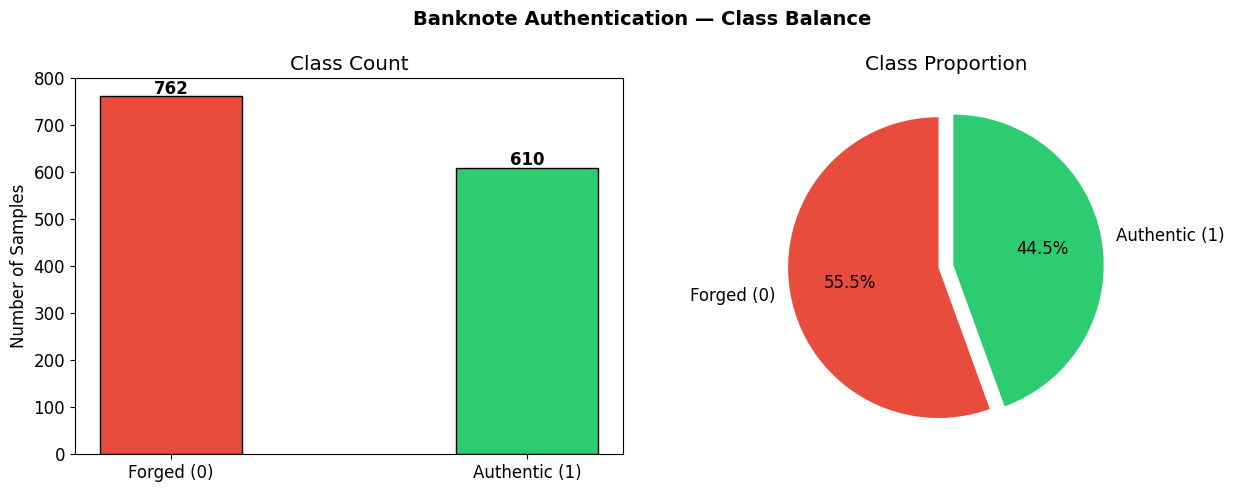

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = [np.sum(y == 0), np.sum(y == 1)]
names  = ['Forged (0)', 'Authentic (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(names, counts, color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Class Count')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=names, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Proportion')

plt.suptitle('Banknote Authentication — Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 2 — Feature Distributions by Class

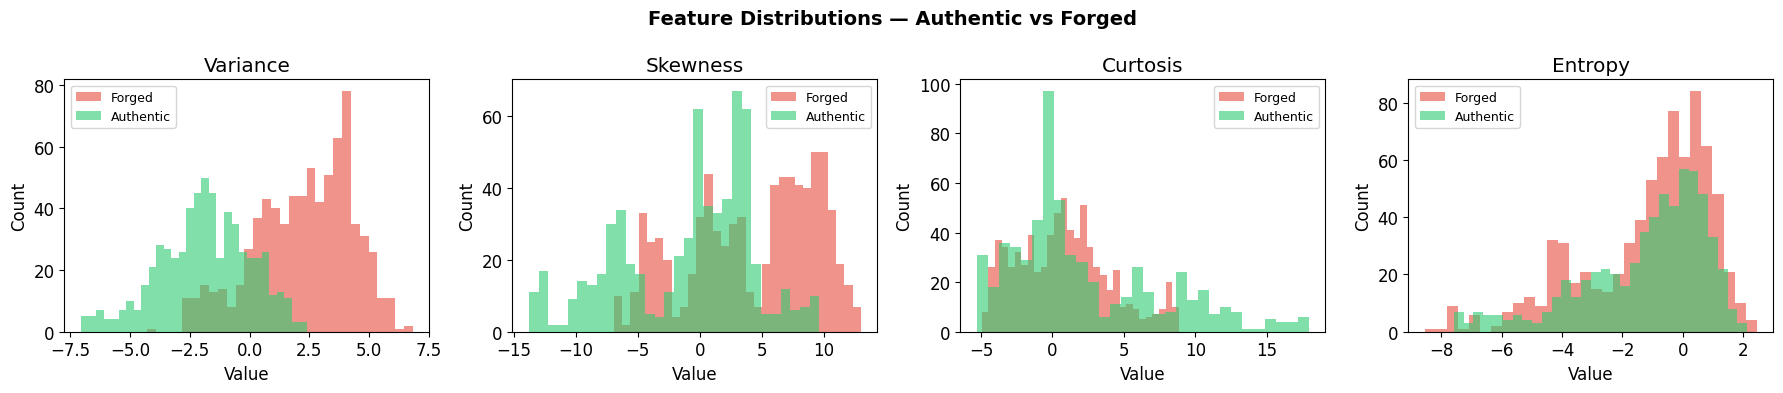

In [4]:
feat_names = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (ax, name) in enumerate(zip(axes, feat_names)):
    ax.hist(X[y==0, i], bins=30, alpha=0.6, color='#e74c3c', label='Forged')
    ax.hist(X[y==1, i], bins=30, alpha=0.6, color='#2ecc71', label='Authentic')
    ax.set_title(name)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions — Authentic vs Forged', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 3 — Feature Correlation Heatmap

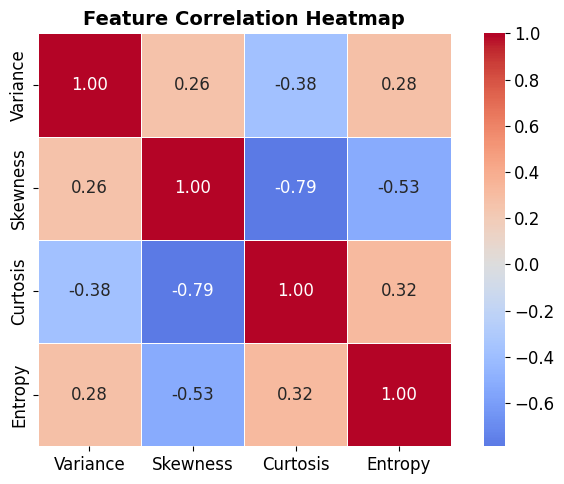

In [5]:
corr = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 1: Logistic Regression with BFGS

### Loss & Gradient Functions

In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def loss_function(w, X, y, lambda1=0.01, lambda2=0.01, epsilon=1e-6):
    probs  = np.clip(sigmoid(X @ w), 1e-12, 1 - 1e-12)
    ce     = -np.mean(y * np.log(probs) + (1 - y) * np.log(1 - probs))
    w_nb   = w[1:]  # no bias regularization
    reg    = lambda1 * np.sum(np.sqrt(w_nb**2 + epsilon)) + lambda2 * np.sum(w_nb**2)
    return ce + reg


def gradient_function(w, X, y, lambda1=0.01, lambda2=0.01, epsilon=1e-6):
    n       = len(y)
    probs   = sigmoid(X @ w)
    g       = (1/n) * X.T @ (probs - y)
    g_l1    = np.zeros_like(w)
    g_l1[1:] = lambda1 * w[1:] / np.sqrt(w[1:]**2 + epsilon)
    g_l2    = np.zeros_like(w)
    g_l2[1:] = 2 * lambda2 * w[1:]
    return g + g_l1 + g_l2

print("loss_function and gradient_function defined.")

loss_function and gradient_function defined.


### Training with BFGS using `scipy.optimize.minimize`

In [7]:
w0 = np.zeros(X_train.shape[1])

result_bfgs = minimize(
    fun=loss_function,
    x0=w0,
    args=(X_train, y_train, 0.01, 0.01, 1e-6),
    method='BFGS',
    jac=gradient_function,
    options={'maxiter': 500, 'disp': True}
)

w_bfgs = result_bfgs.x
print(f"\n{'='*50}")
print(f"BFGS converged: {result_bfgs.success}")
print(f"Iterations: {result_bfgs.nit}")
print(f"Final loss: {result_bfgs.fun:.6f}")

y_prob_bfgs = sigmoid(X_test @ w_bfgs)
y_pred_bfgs = (y_prob_bfgs >= 0.5).astype(int)
acc_bfgs    = accuracy_score(y_test, y_pred_bfgs)
print(f"\nTest Accuracy (Single BFGS): {acc_bfgs:.4f}")
print(confusion_matrix(y_test, y_pred_bfgs))

Optimization terminated successfully.
         Current function value: 0.310567
         Iterations: 23
         Function evaluations: 24
         Gradient evaluations: 24

BFGS converged: True
Iterations: 23
Final loss: 0.310567

Test Accuracy (Single BFGS): 0.9600
[[144   9]
 [  2 120]]


### Training with Gradient Descent (for comparison)

In [8]:
def gradient_descent(X, y, lr=0.1, max_iter=1000, lambda1=0.01, lambda2=0.01, epsilon=1e-6):
    w      = np.zeros(X.shape[1])
    losses = []
    for i in range(max_iter):
        losses.append(loss_function(w, X, y, lambda1, lambda2, epsilon))
        w = w - lr * gradient_function(w, X, y, lambda1, lambda2, epsilon)
    return w, losses

w_gd, losses_gd = gradient_descent(X_train, y_train, lr=0.1, max_iter=1000)

y_pred_gd = (sigmoid(X_test @ w_gd) >= 0.5).astype(int)
acc_gd    = accuracy_score(y_test, y_pred_gd)
print(f"Test Accuracy (Gradient Descent, 1000 iters): {acc_gd:.4f}")

Test Accuracy (Gradient Descent, 1000 iters): 0.9564


### Plot 4 — Convergence Comparison: BFGS vs Gradient Descent

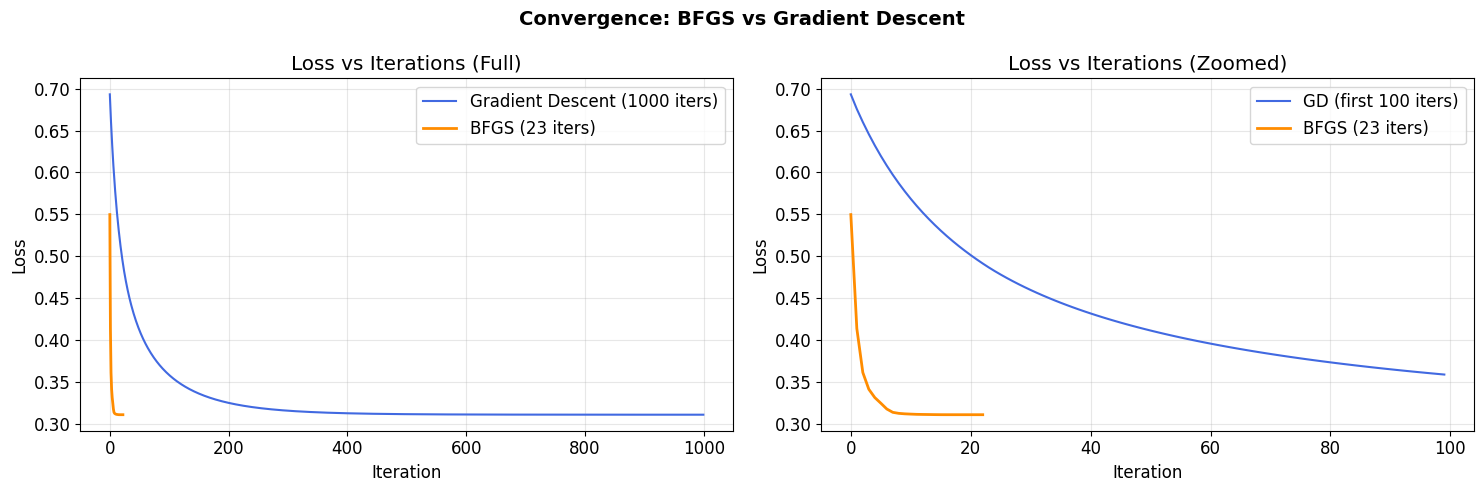

In [9]:
# Track BFGS loss per iteration
losses_bfgs = []
minimize(
    fun=loss_function, x0=w0,
    args=(X_train, y_train, 0.01, 0.01, 1e-6),
    method='BFGS', jac=gradient_function,
    callback=lambda w: losses_bfgs.append(loss_function(w, X_train, y_train)),
    options={'maxiter': 500}
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(losses_gd,               color='royalblue',  label='Gradient Descent (1000 iters)')
axes[0].plot(losses_bfgs,             color='darkorange', label=f'BFGS ({len(losses_bfgs)} iters)', linewidth=2)
axes[0].set_title('Loss vs Iterations (Full)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses_gd[:100],         color='royalblue',  label='GD (first 100 iters)')
axes[1].plot(losses_bfgs,             color='darkorange', label=f'BFGS ({len(losses_bfgs)} iters)', linewidth=2)
axes[1].set_title('Loss vs Iterations (Zoomed)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Convergence: BFGS vs Gradient Descent', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 5 — Learned Feature Weights (BFGS)

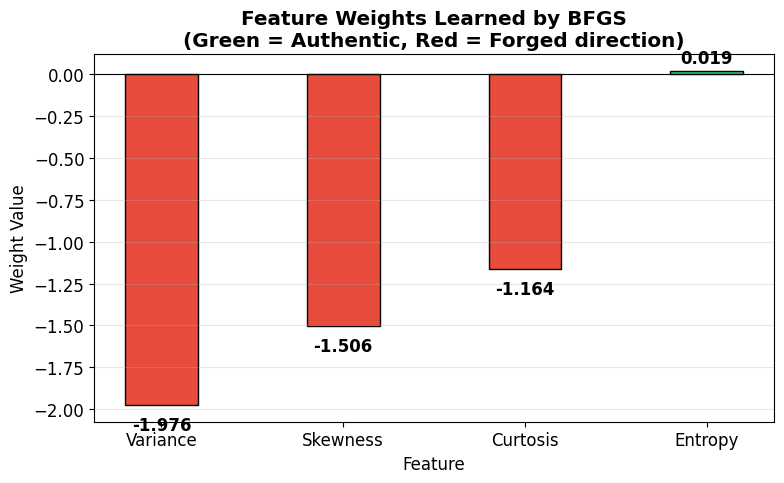

In [10]:
weights    = w_bfgs[1:]   # skip bias
bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in weights]

plt.figure(figsize=(8, 5))
plt.bar(feat_names, weights, color=bar_colors, edgecolor='black', width=0.4)
plt.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(weights):
    plt.text(i, v + (0.05 if v >= 0 else -0.15), f'{v:.3f}', ha='center', fontweight='bold')
plt.title('Feature Weights Learned by BFGS\n(Green = Authentic, Red = Forged direction)',
          fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Weight Value')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 2: Bagging (Parallel Ensemble)
- **K=10** bootstrap samples (sampling with replacement)
- Train BFGS logistic regression on each bootstrap sample
- Average all 10 predicted probabilities for final prediction

In [11]:
def train_bagging(X_train, y_train, K=10, lambda1=0.01, lambda2=0.01, epsilon=1e-6):
    n      = X_train.shape[0]
    models = []
    for k in range(K):
        boot_idx     = np.random.choice(n, size=n, replace=True)
        X_boot       = X_train[boot_idx]
        y_boot       = y_train[boot_idx]
        unique_count = len(set(boot_idx))
        oob_count    = n - unique_count
        w0     = np.zeros(X_boot.shape[1])
        result = minimize(
            fun=loss_function, x0=w0,
            args=(X_boot, y_boot, lambda1, lambda2, epsilon),
            method='BFGS', jac=gradient_function,
            options={'maxiter': 500}
        )
        models.append(result.x)
        print(f"  Model {k+1:2d}/{K}: loss={result.fun:.4f}, "
              f"unique_samples={unique_count}/{n}, OOB={oob_count}")
    return models


def predict_bagging(models, X):
    probs    = np.array([sigmoid(X @ w) for w in models])
    avg_prob = np.mean(probs, axis=0)
    return (avg_prob >= 0.5).astype(int), avg_prob


print("Training Bagging Ensemble (K=10)...")
print("-" * 60)
bagging_models = train_bagging(X_train, y_train, K=10)

y_pred_bag, y_prob_bag = predict_bagging(bagging_models, X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
print(f"\n✅ Test Accuracy (Bagging K=10): {acc_bag:.4f}")

Training Bagging Ensemble (K=10)...
------------------------------------------------------------
  Model  1/10: loss=0.3167, unique_samples=694/1097, OOB=403
  Model  2/10: loss=0.3105, unique_samples=667/1097, OOB=430
  Model  3/10: loss=0.3092, unique_samples=682/1097, OOB=415
  Model  4/10: loss=0.3136, unique_samples=706/1097, OOB=391
  Model  5/10: loss=0.3177, unique_samples=678/1097, OOB=419
  Model  6/10: loss=0.3035, unique_samples=701/1097, OOB=396
  Model  7/10: loss=0.3200, unique_samples=698/1097, OOB=399
  Model  8/10: loss=0.3196, unique_samples=691/1097, OOB=406
  Model  9/10: loss=0.3141, unique_samples=702/1097, OOB=395
  Model 10/10: loss=0.3063, unique_samples=691/1097, OOB=406

✅ Test Accuracy (Bagging K=10): 0.9600


### Plot 6 — Bagging Analysis: Individual vs Ensemble Performance

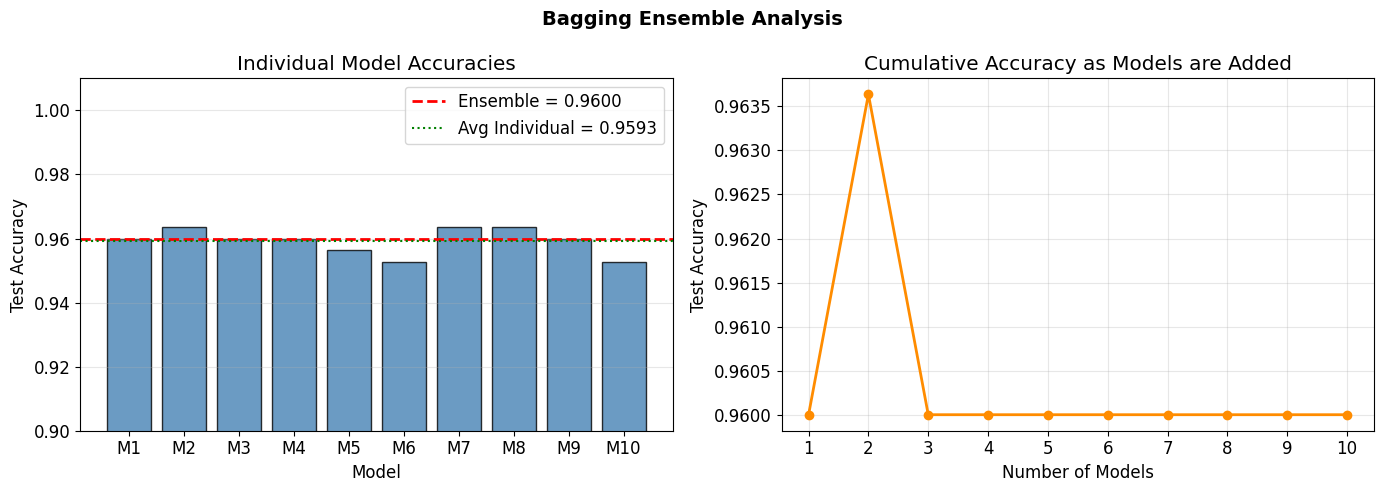

In [12]:
indiv_accs = [
    accuracy_score(y_test, (sigmoid(X_test @ w) >= 0.5).astype(int))
    for w in bagging_models
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: each model accuracy
model_ids = [f'M{i+1}' for i in range(len(bagging_models))]
axes[0].bar(model_ids, indiv_accs, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(acc_bag, color='red',   linestyle='--', linewidth=2,
                label=f'Ensemble = {acc_bag:.4f}')
axes[0].axhline(np.mean(indiv_accs), color='green', linestyle=':', linewidth=1.5,
                label=f'Avg Individual = {np.mean(indiv_accs):.4f}')
axes[0].set_ylim(0.90, 1.01)
axes[0].set_title('Individual Model Accuracies')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test Accuracy')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Cumulative ensemble accuracy
cum_accs = []
for k in range(1, len(bagging_models) + 1):
    _, p = predict_bagging(bagging_models[:k], X_test)
    cum_accs.append(accuracy_score(y_test, (p >= 0.5).astype(int)))

axes[1].plot(range(1, len(bagging_models)+1), cum_accs, 'o-', color='darkorange', linewidth=2)
axes[1].set_title('Cumulative Accuracy as Models are Added')
axes[1].set_xlabel('Number of Models')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_xticks(range(1, len(bagging_models)+1))
axes[1].grid(alpha=0.3)

plt.suptitle('Bagging Ensemble Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Boosting (Sequential Ensemble, 2 Rounds)

In [13]:
def train_boosting(X_train, y_train, eta=0.1, lambda1=0.01, lambda2=0.01, epsilon=1e-6):
    w0 = np.zeros(X_train.shape[1])

    # Round 1: fit on original labels
    print("  Round 1: Training M₁ on original targets y...")
    result1 = minimize(
        fun=loss_function, x0=w0,
        args=(X_train, y_train, lambda1, lambda2, epsilon),
        method='BFGS', jac=gradient_function,
        options={'maxiter': 500}
    )
    w1 = result1.x
    p1 = sigmoid(X_train @ w1)
    print(f"  M₁ loss: {result1.fun:.4f}, converged: {result1.success}")
    print(f"  M₁ train accuracy: {accuracy_score(y_train, (p1>=0.5).astype(int)):.4f}")

    # Compute pseudo-residuals
    residuals = y_train - p1
    print(f"\n  Pseudo-Residuals — Mean: {residuals.mean():.4f}, Std: {residuals.std():.4f}")

    # Round 2: fit on residuals (MSE loss)
    print(f"\n  Round 2: Training M₂ on residuals r = y - σ(Xw₁)...")

    def residual_loss(w, X, r, lambda1, lambda2, epsilon):
        mse  = (1/(2*len(r))) * np.sum((r - X @ w)**2)
        w_nb = w[1:]
        return mse + lambda1 * np.sum(np.sqrt(w_nb**2 + epsilon)) + lambda2 * np.sum(w_nb**2)

    def residual_gradient(w, X, r, lambda1, lambda2, epsilon):
        n          = len(r)
        grad_mse   = -(1/n) * X.T @ (r - X @ w)
        grad_sl1   = np.zeros_like(w)
        grad_sl1[1:] = lambda1 * w[1:] / np.sqrt(w[1:]**2 + epsilon)
        grad_l2    = np.zeros_like(w)
        grad_l2[1:] = 2 * lambda2 * w[1:]
        return grad_mse + grad_sl1 + grad_l2

    result2 = minimize(
        fun=residual_loss, x0=w0,
        args=(X_train, residuals, lambda1, lambda2, epsilon),
        method='BFGS', jac=residual_gradient,
        options={'maxiter': 500}
    )
    w2 = result2.x
    print(f"  M₂ loss: {result2.fun:.4f}, converged: {result2.success}")
    return w1, w2, eta


def predict_boosting(w1, w2, eta, X):
    combined = X @ w1 + eta * (X @ w2)
    prob     = sigmoid(combined)
    return (prob >= 0.5).astype(int), prob


print("Training Boosting (2 rounds, η = 0.1)...")
print("-" * 60)
w1_boost, w2_boost, eta = train_boosting(X_train, y_train, eta=0.1)

y_pred_boost, y_prob_boost = predict_boosting(w1_boost, w2_boost, eta, X_test)
acc_boost = accuracy_score(y_test, y_pred_boost)
print(f"\n✅ Test Accuracy (Boosting, η=0.1): {acc_boost:.4f}")

y_pred_m1_only = (sigmoid(X_test @ w1_boost) >= 0.5).astype(int)
acc_m1_only    = accuracy_score(y_test, y_pred_m1_only)
print(f"   M₁ alone accuracy:       {acc_m1_only:.4f}")
print(f"   M₁ + η·M₂ accuracy:     {acc_boost:.4f}")
print(f"   Improvement from boosting: {acc_boost - acc_m1_only:+.4f}")

Training Boosting (2 rounds, η = 0.1)...
------------------------------------------------------------
  Round 1: Training M₁ on original targets y...
  M₁ loss: 0.3106, converged: True
  M₁ train accuracy: 0.9699

  Pseudo-Residuals — Mean: 0.0000, Std: 0.2040

  Round 2: Training M₂ on residuals r = y - σ(Xw₁)...
  M₂ loss: 0.0162, converged: True

✅ Test Accuracy (Boosting, η=0.1): 0.9600
   M₁ alone accuracy:       0.9600
   M₁ + η·M₂ accuracy:     0.9600
   Improvement from boosting: +0.0000


---
## Part 4: Final Comparison — All Methods

In [14]:
print("=" * 60)
print("   FINAL COMPARISON — Banknote Authentication Dataset")
print("=" * 60)
print(f"{'Method':<28} {'Test Accuracy':>14}")
print("-" * 44)
print(f"{'Single BFGS':<28} {acc_bfgs:>14.4f}")
print(f"{'Gradient Descent (1000 it)':<28} {acc_gd:>14.4f}")
print(f"{'Bagging (K=10)':<28} {acc_bag:>14.4f}")
print(f"{'Boosting (η=0.1)':<28} {acc_boost:>14.4f}")
print("=" * 60)

   FINAL COMPARISON — Banknote Authentication Dataset
Method                        Test Accuracy
--------------------------------------------
Single BFGS                          0.9600
Gradient Descent (1000 it)           0.9564
Bagging (K=10)                       0.9600
Boosting (η=0.1)                     0.9600


### Plot 7 — Final Accuracy Comparison

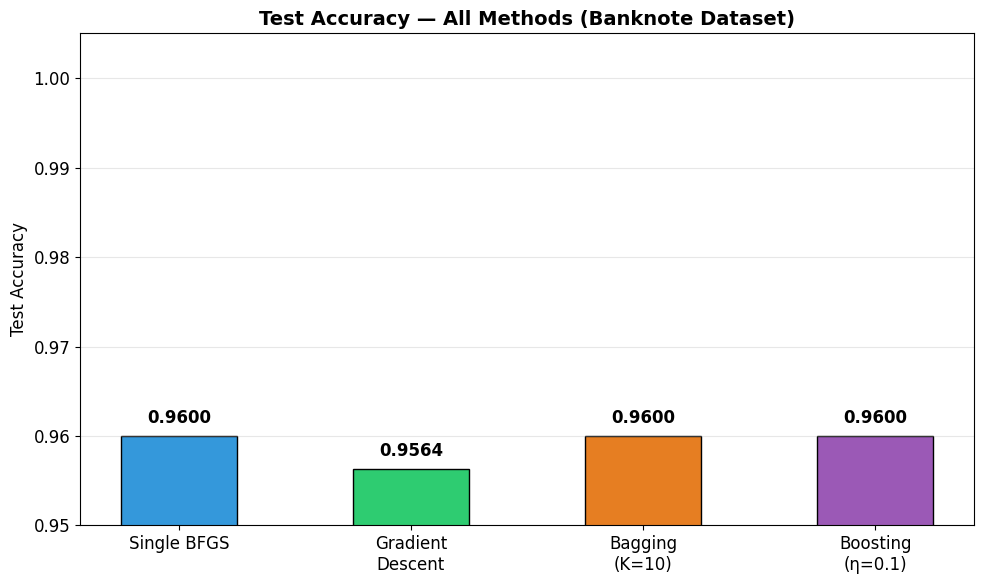

In [15]:
methods     = ['Single BFGS', 'Gradient\nDescent', 'Bagging\n(K=10)', 'Boosting\n(η=0.1)']
accuracies  = [acc_bfgs, acc_gd, acc_bag, acc_boost]
bar_colors  = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0.95, 1.005)
plt.title('Test Accuracy — All Methods (Banknote Dataset)', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 8 — Confusion Matrices: All Methods

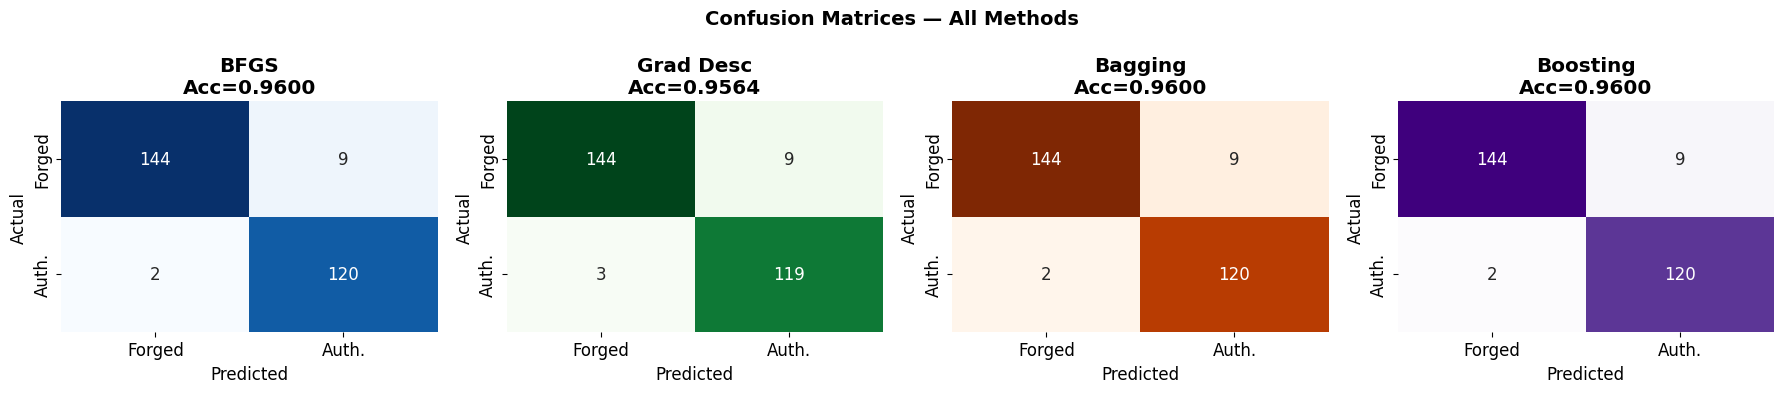

In [16]:
all_preds  = [y_pred_bfgs, y_pred_gd,   y_pred_bag,   y_pred_boost]
all_names  = ['BFGS',      'Grad Desc', 'Bagging',    'Boosting']
all_cmaps  = ['Blues',     'Greens',    'Oranges',    'Purples']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, preds, name, cmap in zip(axes, all_preds, all_names, all_cmaps):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Forged', 'Auth.'],
                yticklabels=['Forged', 'Auth.'], cbar=False)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test, preds):.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 9 — ROC Curves: All Methods

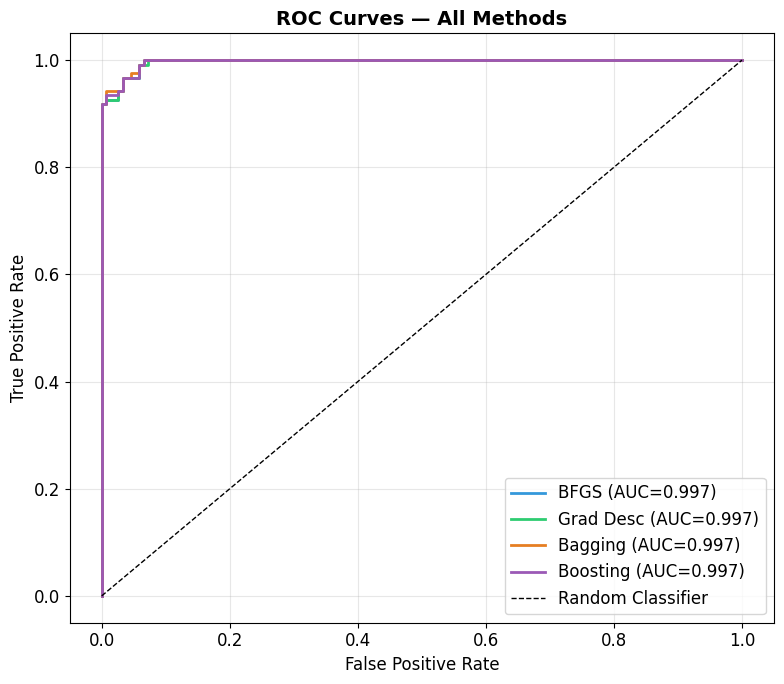

In [17]:
all_probs  = [y_prob_bfgs, sigmoid(X_test @ w_gd), y_prob_bag, y_prob_boost]
roc_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

plt.figure(figsize=(8, 7))
for probs, name, color in zip(all_probs, all_names, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Methods', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 10 — Predicted Probability Distributions

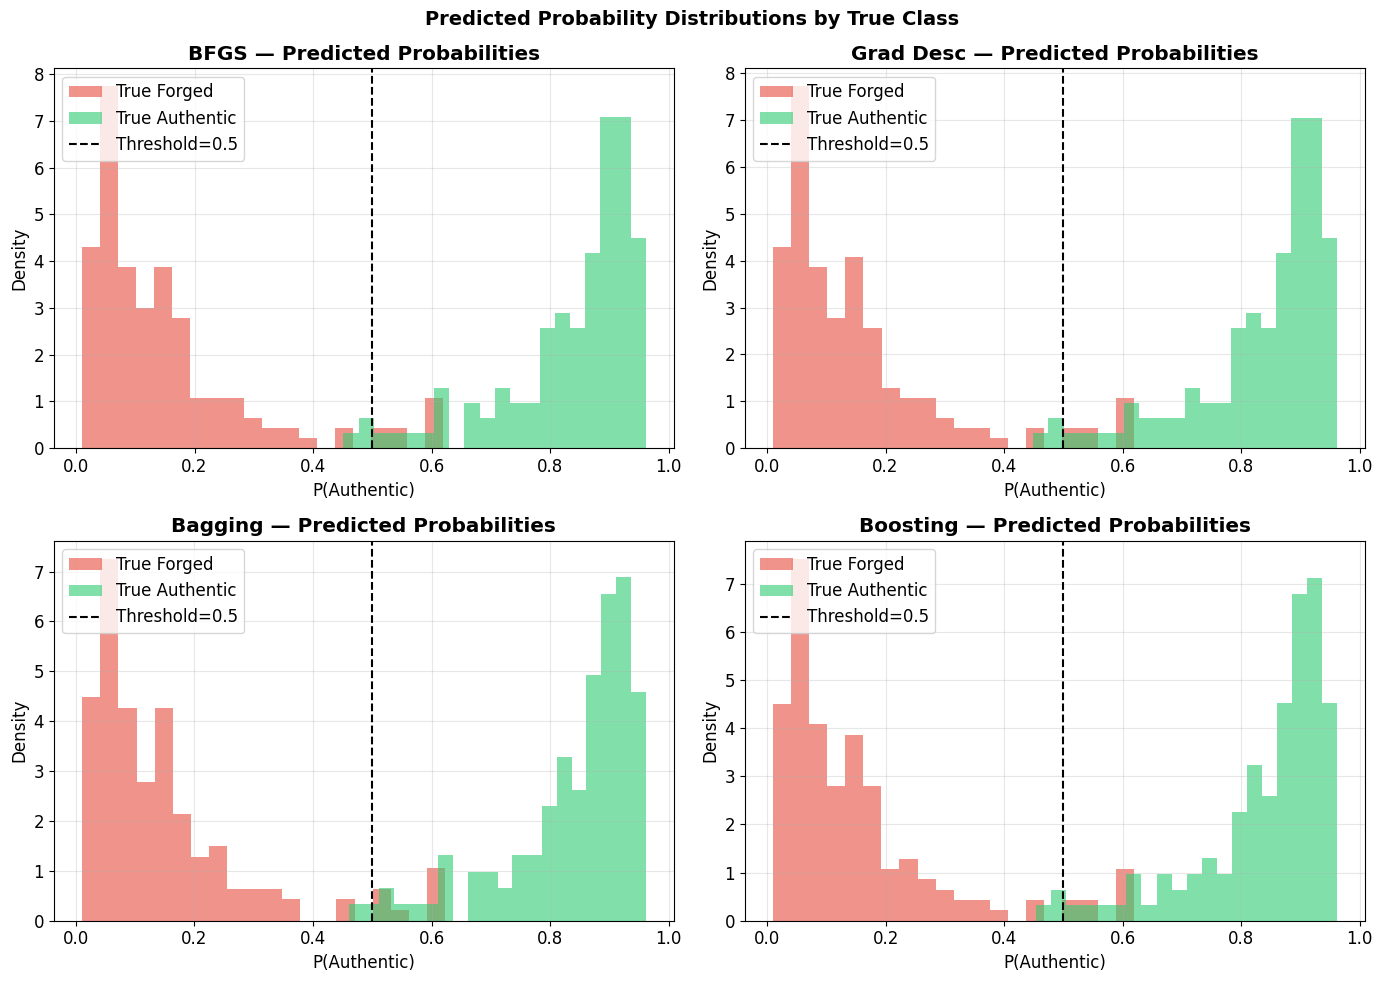

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, probs, name in zip(axes, all_probs, all_names):
    ax.hist(probs[y_test == 0], bins=20, alpha=0.6, color='#e74c3c', label='True Forged',    density=True)
    ax.hist(probs[y_test == 1], bins=20, alpha=0.6, color='#2ecc71', label='True Authentic', density=True)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
    ax.set_title(f'{name} — Predicted Probabilities', fontweight='bold')
    ax.set_xlabel('P(Authentic)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Predicted Probability Distributions by True Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()